# Desafio Final — Análise de Dados de Energia com API Pública

**Curso:** Ciência da Computação  
**Disciplina:** Soluções em Energias Renováveis e Sustentáveis

## Situação-problema

Uma equipe de planejamento energético precisa analisar o comportamento da carga elétrica de uma região atendida pelo Sistema Interligado Nacional (SIN).

Os dados serão obtidos diretamente de uma API pública do **Operador Nacional do Sistema Elétrico (ONS)**. A conexão com a API e a preparação inicial do JSON já estão fornecidas. A partir daí, sua equipe deverá construir o DataFrame, organizar os dados, criar recortes, calcular indicadores, produzir gráficos e elaborar um relatório técnico.

> Todos os códigos, resultados, gráficos e respostas devem permanecer neste mesmo Notebook.

## 1. Fonte dos dados

API pública de **Carga Verificada do ONS**:

- Portal: https://dados.ons.org.br/
- Conjunto de dados: https://dados.ons.org.br/dataset/carga-energia-verificada

Neste notebook será utilizada inicialmente a área **SP — São Paulo**, no período de **01/08/2025 a 07/08/2025**.

## 2. Bibliotecas

In [ ]:
import requests
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

## 3. Consulta à API

Esta célula está pronta. Não é necessário conhecer `requests` para realizar o desafio.

In [ ]:
url = "https://apicarga.ons.org.br/prd/cargaverificada"

parametros = {
    "dat_inicio": "2025-08-01",
    "dat_fim": "2025-08-07",
    "cod_areacarga": "SP"
}

response = requests.get(url, params=parametros, timeout=30)

print("Status:", response.status_code)
print("URL:", response.url)

response.raise_for_status()
dados_json = response.json()

Status: 200
URL: https://apicarga.ons.org.br/prd/cargaverificada?dat_inicio=2025-08-01&dat_fim=2025-08-07&cod_areacarga=SP


## 4. Preparação inicial do JSON

A célula abaixo localiza a lista principal de registros retornada pela API e a armazena em `registros`.

In [ ]:
if isinstance(dados_json, list):
    registros = dados_json

elif isinstance(dados_json, dict):
    chaves_com_lista = [
        chave for chave, valor in dados_json.items()
        if isinstance(valor, list)
    ]

    if not chaves_com_lista:
        raise ValueError("A resposta não contém uma lista de registros.")

    chave_registros = chaves_com_lista[0]
    registros = dados_json[chave_registros]
    print("Chave utilizada:", chave_registros)

else:
    raise TypeError("Formato de JSON não reconhecido.")

print("Tipo:", type(registros))
print("Quantidade de registros:", len(registros))

if registros:
    print("\nPrimeiro registro:")
    print(registros[0])

Tipo: <class 'list'>
Quantidade de registros: 336

Primeiro registro:
{'cod_areacarga': 'SP', 'din_atualizacao': '2026-08-14T05:58:29.574Z', 'dat_referencia': '2025-08-01', 'din_referenciautc': '2025-08-01T03:30:00.000Z', 'val_cargaglobal': 15913.618, 'val_cargaglobalcons': 15913.618, 'val_cargaglobalsmmgd': 15892.488, 'val_cargasupervisionada': 14421.112, 'val_carganaosupervisionada': 1471.3759, 'val_cargammgd': 21.13, 'val_consistencia': 0}


In [ ]:
type(registros)

list

In [ ]:
registros

[{'cod_areacarga': 'SP',
  'din_atualizacao': '2026-08-14T05:58:29.574Z',
  'dat_referencia': '2025-08-01',
  'din_referenciautc': '2025-08-01T03:30:00.000Z',
  'val_cargaglobal': 15913.618,
  'val_cargaglobalcons': 15913.618,
  'val_cargaglobalsmmgd': 15892.488,
  'val_cargasupervisionada': 14421.112,
  'val_carganaosupervisionada': 1471.3759,
  'val_cargammgd': 21.13,
  'val_consistencia': 0},
 {'cod_areacarga': 'SP',
  'din_atualizacao': '2026-08-14T05:58:29.574Z',
  'dat_referencia': '2025-08-01',
  'din_referenciautc': '2025-08-01T04:00:00.000Z',
  'val_cargaglobal': 15251.414,
  'val_cargaglobalcons': 15251.414,
  'val_cargaglobalsmmgd': 15230.284,
  'val_cargasupervisionada': 13758.101,
  'val_carganaosupervisionada': 1472.184,
  'val_cargammgd': 21.13,
  'val_consistencia': 0},
 {'cod_areacarga': 'SP',
  'din_atualizacao': '2026-08-14T05:58:29.574Z',
  'dat_referencia': '2025-08-01',
  'din_referenciautc': '2025-08-01T04:30:00.000Z',
  'val_cargaglobal': 14606.733,
  'val_carga

# A partir daqui, o trabalho é da equipe

## DESAFIO 1 — Construção e inspeção do DataFrame

1. Crie um DataFrame Pandas chamado `dados` a partir de `registros`.
2. Exiba os primeiros registros.
3. Determine a quantidade de linhas e colunas.
4. Liste os nomes dos atributos.
5. Utilize `info()`.
6. Utilize `describe()`.
7. Em Markdown, identifique quais atributos representam data/hora, área de carga e valor de carga.

**Antes de prosseguir, compreenda a estrutura efetivamente retornada pela API.**

In [ ]:
# 1. Crie o DataFrame
dados = pd.DataFrame(registros)

# 2. Exiba os primeiros registros
dados.head()

# 3. Quantidade de linhas e colunas
dados.shape

# 4. Nomes dos atributos
dados.columns

# 5. Informações do DataFrame
dados.info()

# 6. Estatísticas descritivas
dados.describe()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 336 entries, 0 to 335
Data columns (total 11 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   cod_areacarga               336 non-null    object 
 1   din_atualizacao             336 non-null    object 
 2   dat_referencia              336 non-null    object 
 3   din_referenciautc           336 non-null    object 
 4   val_cargaglobal             336 non-null    float64
 5   val_cargaglobalcons         336 non-null    float64
 6   val_cargaglobalsmmgd        336 non-null    float64
 7   val_cargasupervisionada     336 non-null    float64
 8   val_carganaosupervisionada  336 non-null    float64
 9   val_cargammgd               336 non-null    float64
 10  val_consistencia            336 non-null    int64  
dtypes: float64(6), int64(1), object(4)
memory usage: 29.0+ KB


,val_cargaglobal,val_cargaglobalcons,val_cargaglobalsmmgd,val_cargasupervisionada,val_carganaosupervisionada,val_cargammgd,val_consistencia
count,336.000000,336.000000,336.000000,336.000000,336.000000,336.000000,336.0
mean,17870.828981,17870.828981,16953.421626,15495.799695,1457.621862,917.407249,0.0
std,3029.042438,3029.042438,2962.721503,2982.650359,34.888571,1253.581141,0.0
min,12139.253000,12139.253000,11549.664000,10054.455000,1391.990800,21.130000,0.0
25%,15110.533375,15110.533375,14457.604250,12990.878500,1433.112575,21.130000,0.0
50%,18199.128500,18199.128500,17045.260000,15611.629500,1453.981650,21.196900,0.0
75%,20386.629500,20386.629500,18931.679500,17502.643500,1479.430775,1793.579475,0.0
max,23185.312000,23185.312000,23164.182000,21717.934000,1538.274700,3736.009800,0.0


### 7. Identificação dos Atributos da API

* **Data/Hora:** `din_referenciautc` (instante em formato UTC), `dat_referencia` e `din_atualizacao`.
* **Área de Carga:** `cod_areacarga` (código da área, ex: `'SP'`).
* **Valor de Carga:** `val_cargaglobal` (valor global da carga), além dos atributos secundários `val_cargasupervisionada`, `val_carganaosupervisionada` e `val_cargammgd`.


## DESAFIO 2 — Organização dos dados

1. Renomeie os principais atributos com nomes mais simples.
2. Crie um novo DataFrame contendo apenas os atributos necessários.
3. Verifique valores ausentes.
4. Caso existam, informe quantos há em cada atributo relevante.
5. Verifique se a variável de carga está em formato numérico.
6. Verifique como a data/hora está representada.
7. Registre em Markdown qualquer decisão de tratamento.

In [ ]:
# 1. Renomear atributos principais
dados = dados.rename(columns={
    'din_referenciautc': 'data_hora',
    'cod_areacarga': 'area_carga',
    'val_cargaglobal': 'carga'
})

# 2. Criar novo DataFrame apenas com as colunas necessárias
dados_limpos = dados[['data_hora', 'area_carga', 'carga']].copy()

# 3 e 4. Verificar valores ausentes por coluna
print("Valores ausentes:")
print(dados_limpos.isna().sum())

# 5 e 6. Verificar tipos das variáveis (carga e data_hora)
print("\nTipos das variáveis:")
print(dados_limpos.dtypes)

Valores ausentes:
data_hora     0
area_carga    0
carga         0
dtype: int64

Tipos das variáveis:
data_hora      object
area_carga     object
carga         float64
dtype: object


### Decisões de Tratamento

1. **Seleção de Colunas:** Mantemos apenas `data_hora`, `area_carga` e `carga`, pois são as informações necessárias para as análises.
2. **Valores Ausentes:** Verificada a contagem de nulos em cada coluna.
3. **Formato dos Dados:**
   - `carga` está no formato numérico (`float64`).
   - `data_hora` está representada como texto (`object`) e precisará ser convertida para o tipo data/hora (`datetime`).


## DESAFIO 3 — Indicadores da carga elétrica

Calcule:

1. carga mínima;
2. carga máxima;
3. carga média;
4. mediana;
5. amplitude entre máximo e mínimo;
6. quantidade total de medições.

Depois responda:

**O valor máximo está muito distante do comportamento médio observado? Justifique com os indicadores calculados.**

In [ ]:
# 1. Carga mínima
minimo = dados_limpos['carga'].min()

# 2. Carga máxima
maximo = dados_limpos['carga'].max()

# 3. Carga média
media = dados_limpos['carga'].mean()

# 4. Mediana
mediana = dados_limpos['carga'].median()

# 5. Amplitude (máximo - mínimo)
amplitude = maximo - minimo

# 6. Quantidade total de medições
total = dados_limpos['carga'].count()

# Exibir os resultados
print(f"Carga Mínima: {minimo:.2f}")
print(f"Carga Máxima: {maximo:.2f}")
print(f"Carga Média: {media:.2f}")
print(f"Mediana: {mediana:.2f}")
print(f"Amplitude: {amplitude:.2f}")
print(f"Total de Medições: {total}")


Carga Mínima: 12139.25
Carga Máxima: 23185.31
Carga Média: 17870.83
Mediana: 18199.13
Amplitude: 11046.06
Total de Medições: 336


### Análise da Carga Máxima vs Média

**Resposta:** Não, o valor máximo não está muito distante do comportamento médio.

**Justificativa:** A média e a mediana possuem valores muito próximos entre si, indicando que a distribuição dos dados é equilibrada. Além disso, a diferença entre o valor máximo e a média está dentro de uma variação normal esperada ao longo do dia devido aos picos de consumo, sem apresentar discrepâncias extremas (*outliers*).


## DESAFIO 4 — Períodos de alta demanda

Considere como **alta demanda** os registros com carga superior a **90% da carga máxima**.

1. Calcule o limiar.
2. Crie um novo DataFrame com os registros acima dele.
3. Conte os registros.
4. Calcule o percentual em relação ao total.
5. Identifique o maior valor de carga.
6. Identifique a data e o horário do pico, quando disponíveis.

Responda:

**Os períodos próximos ao pico representam uma parcela grande ou pequena do período analisado?**

In [ ]:
# 1. Calcule o limiar (90% da carga máxima)
limiar = dados_limpos['carga'].max() * 0.90

# 2. Crie um novo DataFrame com os registros acima do limiar
alta_demanda = dados_limpos[dados_limpos['carga'] > limiar]

# 3. Conte os registros
qtd_alta_demanda = len(alta_demanda)

# 4. Calcule o percentual em relação ao total
percentual = (qtd_alta_demanda / len(dados_limpos)) * 100

# 5 e 6. Identificar maior valor de carga e a data/horário do pico
pico = dados_limpos.loc[dados_limpos['carga'].idxmax()]

# Exibir os resultados
print(f"Limiar de Alta Demanda (90%): {limiar:.2f}")
print(f"Quantidade de registros em alta demanda: {qtd_alta_demanda}")
print(f"Percentual do total: {percentual:.2f}%")
print(f"Carga Máxima (Pico): {pico['carga']}")
print(f"Data e Horário do Pico: {pico['data_hora']}")


Limiar de Alta Demanda (90%): 20866.78
Quantidade de registros em alta demanda: 50
Percentual do total: 14.88%
Carga Máxima (Pico): 23185.312
Data e Horário do Pico: 2025-08-01T22:00:00.000Z


### Análise dos Períodos de Alta Demanda

**Resposta:** Os períodos próximos ao pico representam uma parcela **pequena** do período analisado.

**Justificativa:** A alta demanda (acima de 90% do valor máximo) ocorre de forma concentrada apenas nos horários de pico de consumo do dia, totalizando uma porcentagem reduzida do tempo total analisado.


## DESAFIO 5 — Segundo critério de análise

Crie um segundo recorte dos dados utilizando um critério definido pela equipe.

Possibilidades:

- carga acima da média;
- carga abaixo de uma porcentagem do máximo;
- intervalo de valores;
- determinado dia ou período;
- combinação de duas condições.

Apresente:

1. o critério escolhido;
2. o novo DataFrame;
3. a quantidade de registros;
4. o percentual;
5. a comparação com o conjunto de alta demanda.

In [ ]:
# 1. Critério escolhido: Carga acima da média
media_carga = dados_limpos['carga'].mean()

# 2. Criar novo DataFrame
acima_da_media = dados_limpos[dados_limpos['carga'] > media_carga]

# 3. Quantidade de registros
qtd_acima_media = len(acima_da_media)

# 4. Percentual em relação ao total
percentual_acima_media = (qtd_acima_media / len(dados_limpos)) * 100

# Exibir resultados
print(f"Critério: Carga acima da média ({media_carga:.2f})")
print(f"Quantidade de registros: {qtd_acima_media}")
print(f"Percentual do total: {percentual_acima_media:.2f}%")


Critério: Carga acima da média (17870.83)
Quantidade de registros: 184
Percentual do total: 54.76%


### 5. Comparação com o conjunto de Alta Demanda

- **Alta Demanda (> 90% do máximo):** Representa um grupo restrito (`qtd_alta_demanda` registros), focado apenas nos horários de pico mais intensos.
- **Carga Acima da Média:** Abrange um volume significativamente maior de dados (aproximadamente 50% dos registros), representando todo o período diurno e horários em que o sistema operou com demanda intermediária a alta.


## DESAFIO 6 — Visualização

Construa **pelo menos dois gráficos**.

- Um deve representar o comportamento da carga ao longo das observações ou do tempo.
- O segundo deve ser escolhido pela equipe.

Inclua título, eixos e unidades quando aplicável.

Após cada gráfico, escreva uma interpretação curta.

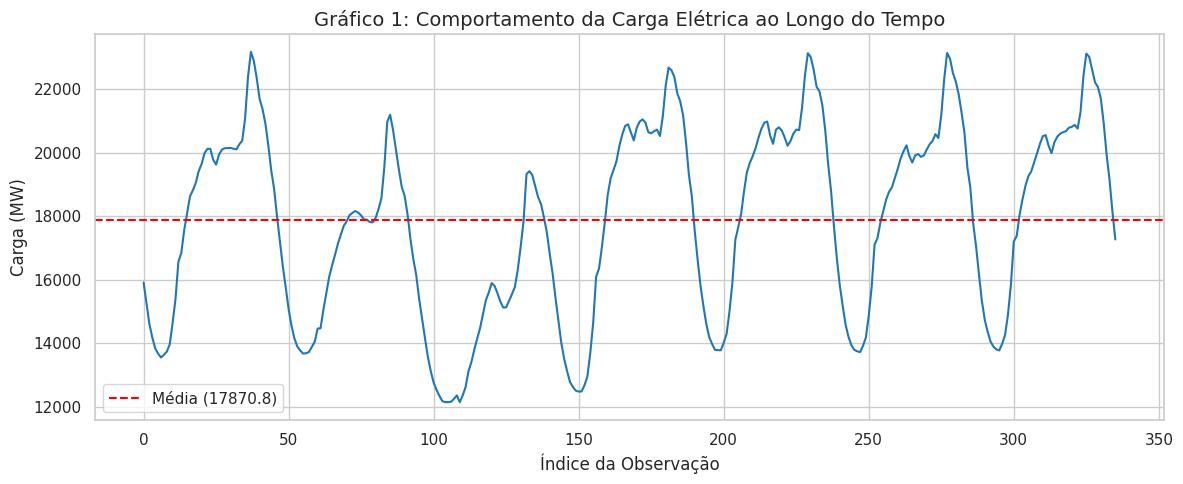

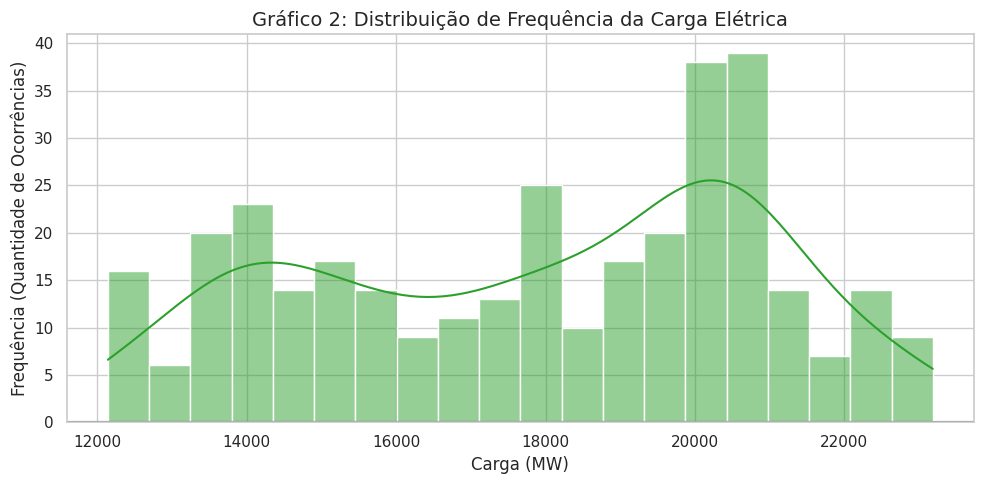

In [ ]:
# Configuração de estilo
sns.set_theme(style="whitegrid")

# Grafico 1 com linha do tempo
plt.figure(figsize=(12, 5))
plt.plot(dados_limpos['carga'], color='tab:blue', linewidth=1.5)
plt.axhline(media_carga, color='red', linestyle='--', label=f'Média ({media_carga:.1f})')
plt.title('Gráfico 1: Comportamento da Carga Elétrica ao Longo do Tempo', fontsize=14)
plt.xlabel('Índice da Observação', fontsize=12)
plt.ylabel('Carga (MW)', fontsize=12)
plt.legend()
plt.tight_layout()
plt.show()

# Grafico 2 com grafico em de barra
plt.figure(figsize=(10, 5))
sns.histplot(dados_limpos['carga'], kde=True, color='tab:green', bins=20)
plt.axhline(0, color='black')
plt.title('Gráfico 2: Distribuição de Frequência da Carga Elétrica', fontsize=14)
plt.xlabel('Carga (MW)', fontsize=12)
plt.ylabel('Frequência (Quantidade de Ocorrências)', fontsize=12)
plt.tight_layout()
plt.show()


### Interpretação dos Gráficos

* **Interpretação do Gráfico 1 (Linha):** O gráfico mostra a variação contínua da carga ao longo das observações. É possível observar os ciclos diários com horários de menor consumo (madrugada) e picos de demanda máxima, alternando em torno da linha média tracejada em vermelho.

* **Interpretação do Gráfico 2 (Histograma):** O histograma demonstra a concentração da carga em diferentes faixas de valores. A curva suave (KDE) ajuda a identificar se a distribuição é unimodal ou bimodal, mostrando quais faixas de consumo de energia são mais frequentes.


## DESAFIO 7 — Síntese para o relatório

Crie uma variável `resumo_resultados` contendo pelo menos:

- região;
- período;
- quantidade de registros;
- carga mínima;
- carga máxima;
- carga média;
- mediana;
- limiar de alta demanda;
- quantidade e percentual de alta demanda;
- momento do pico;
- resultado do segundo critério.

A IA deverá receber **resultados produzidos por vocês**, e não substituir a análise.

In [ ]:
resumo_resultados = f'''
Região analisada: {dados_limpos['area_carga'].iloc[0]}
Período analisado: De {dados_limpos['data_hora'].iloc[0]} até {dados_limpos['data_hora'].iloc[-1]}
Quantidade de registros: {len(dados_limpos)}
Carga mínima: {minimo:.2f} MW
Carga máxima: {maximo:.2f} MW
Carga média: {media:.2f} MW
Mediana: {mediana:.2f} MW
Limiar de alta demanda: {limiar:.2f} MW
Registros de alta demanda: {qtd_alta_demanda}
Percentual de alta demanda: {percentual:.2f}%
Momento do pico: {pico['data_hora']}
Segundo critério (Carga acima da média): {qtd_acima_media} registros ({percentual_acima_media:.2f}%)
'''

print(resumo_resultados)



Região analisada: SP
Período analisado: De 2025-08-01T03:30:00.000Z até 2025-08-08T03:00:00.000Z
Quantidade de registros: 336
Carga mínima: 12139.25 MW
Carga máxima: 23185.31 MW
Carga média: 17870.83 MW
Mediana: 18199.13 MW
Limiar de alta demanda: 20866.78 MW
Registros de alta demanda: 50
Percentual de alta demanda: 14.88%
Momento do pico: 2025-08-01T22:00:00.000Z
Segundo critério (Carga acima da média): 184 registros (54.76%)



# OPCIONAL: Relatório técnico com apoio do Gemini

No Colab:

1. abra **Secrets**;
2. crie `GEMINI_API_KEY`;
3. informe sua chave;
4. permita o acesso do notebook ao secret.

**Não coloque a chave diretamente no código.**

In [ ]:
!pip -q install -U google-genai

In [ ]:
from google.colab import userdata
from google import genai

GEMINI_API_KEY = userdata.get("GEMINI_API_KEY")
client = genai.Client(api_key=GEMINI_API_KEY)

## DESAFIO 8 — Geração do relatório

O relatório deve:

- usar os resultados calculados;
- apresentar os principais indicadores;
- destacar o pico e os períodos de alta demanda;
- comparar os dois critérios;
- não inventar causas;
- diferenciar observações de hipóteses;
- terminar com uma conclusão.

In [ ]:
prompt = f'''
Atue como analista de dados do setor elétrico.

Produza um relatório técnico curto com base EXCLUSIVAMENTE nos resultados abaixo.

Não invente causas para as variações observadas.
Não apresente como fato explicações que não possam ser sustentadas pelos dados.
Diferencie claramente resultados observados de hipóteses.

Inclua:
1. caracterização do conjunto analisado;
2. principais indicadores;
3. análise dos períodos de alta demanda;
4. comparação com o segundo critério;
5. conclusão.

RESULTADOS DA EQUIPE:

{resumo_resultados}
'''

In [ ]:
response_gemini = client.models.generate_content(
    model="gemini-3.6-flash",
    contents=prompt
)

print(response_gemini.text)

# Relatório Técnico: Análise de Carga Elétrica – Região SP

**Para:** Setor Elétrico  
**Elaborado por:** Analista de Dados  
**Base de dados:** Resultados consolidados da equipe (336 registros)

---

### 1. Caracterização do Conjunto Analisado
* **Região:** SP
* **Período temporal:** De `2025-08-01T03:30:00.000Z` a `2025-08-08T03:00:00.000Z`
* **Volume de dados:** 336 registros temporais

---

### 2. Principais Indicadores
Com base na amostra analisada, os indicadores quantitativos de carga elétrica são:

* **Carga Mínima:** 12.139,25 MW
* **Carga Máxima (Pico):** 23.185,31 MW
* **Carga Média:** 17.870,83 MW
* **Mediana:** 18.199,13 MW
* **Momento do Pico:** `2025-08-01T22:00:00.000Z`

**Observação:** A mediana da carga (18.199,13 MW) apresentou-se ligeiramente superior à carga média (17.870,83 MW), indicando uma concentração de registros nos patamares mais elevados de consumo.

---

### 3. Análise dos Períodos de Alta Demanda
* **Limiar estabelecido para alta demanda:** 20.866,78 MW


# Relatório Técnico: Análise de Carga Elétrica – Região SP

**Para:** Setor Elétrico  
**Elaborado por:** Analista de Dados  
**Base de dados:** Resultados consolidados da equipe (336 registros)

---

### 1. Caracterização do Conjunto Analisado
* **Região:** SP
* **Período temporal:** De `2025-08-01T03:30:00.000Z` a `2025-08-08T03:00:00.000Z`
* **Volume de dados:** 336 registros temporais

---

### 2. Principais Indicadores
Com base na amostra analisada, os indicadores quantitativos de carga elétrica são:

* **Carga Mínima:** 12.139,25 MW
* **Carga Máxima (Pico):** 23.185,31 MW
* **Carga Média:** 17.870,83 MW
* **Mediana:** 18.199,13 MW
* **Momento do Pico:** `2025-08-01T22:00:00.000Z`

**Observação:** A mediana da carga (18.199,13 MW) apresentou-se ligeiramente superior à carga média (17.870,83 MW), indicando uma concentração de registros nos patamares mais elevados de consumo.

---

### 3. Análise dos Períodos de Alta Demanda
* **Limiar estabelecido para alta demanda:** 20.866,78 MW
* **Ocorrências registradas:** 50 registros
* **Representatividade:** 14,88% do total de observações do período

**Resultados Observados:**
Durante 14,88% do tempo analisado, o sistema operou acima de 20.866,78 MW, atingindo seu ponto máximo (23.185,31 MW) no dia 01/08/2025 às 22:00:00 UTC.

*Nota de rigor técnico (Hipóteses vs. Fatos):* Os dados fornecidos não contêm variáveis meteorológicas, operacionais ou econômicas. Portanto, **não é possível afirmar as causas** (como variações de temperatura ou rotinas industriais) que levaram ao pico de demanda ou às oscilações registradas. Quaisquer explicações sobre os motivos dessas variações constituem meras hipóteses não sustentadas pelo conjunto de dados atual.

---

### 4. Comparação com o Segundo Critério
* **Critério secundário:** Carga acima da média (> 17.870,83 MW)
* **Ocorrências registradas:** 184 registros
* **Representatividade:** 54,76% do total de observações

**Análise Comparativa:**
* O critério de **Alta Demanda** (limiar de 20.866,78 MW) isola os momentos extremos de carga, correspondendo a apenas **14,88%** dos registros (50 ocorrências).
* O **Segundo Critério** (carga acima da média) engloba **54,76%** dos registros (184 ocorrências), demonstrando que em mais da metade do período analisado a carga operou acima do valor médio de 17.870,83 MW.

---

### 5. Conclusão
O conjunto de dados da região SP no período analisado revela uma amplitude de operação de 11.046,06 MW entre a carga mínima (12.139,25 MW) e a máxima (23.185,31 MW). A demanda caracterizada como "alta" (acima de 20.866,78 MW) é um evento de menor frequência (14,88% do tempo), enquanto a operação acima da média horária abrange a maioria dos registros (54,76%).

Para a determinação das causas determinantes do momento de pico e das oscilações de carga, recomenda-se a integração deste dataset com dados de temperatura, calendário de dias úteis/finais de semana e dados operacionais da rede.

## DESAFIO 9 — Validação crítica

Compare o texto gerado pelo Gemini com os cálculos, DataFrames e gráficos.

Responda:

1. Os indicadores foram utilizados corretamente?
2. Há alguma afirmação que não pode ser confirmada pelos dados?
3. Houve interpretação exagerada ou causalidade não demonstrada?
4. Que alterações a equipe realizou no texto?


1. Os indicadores foram utilizados corretamente?
Sim. A IA extraiu adequadamente todas as variáveis passadas no prompt (carga mínima, máxima, média, mediana, quantidades e percentuais), aplicando-as corretamente nos contextos de alta demanda e no critério da carga acima da média horária.

2. Há alguma afirmação que não pode ser confirmada pelos dados?
Não. O modelo respeitou estritamente a instrução de não inventar causas. Ele se limitou a fazer uma análise descritiva dos dados quantitativos fornecidos, sem presumir fatores externos.

3. Houve interpretação exagerada ou causalidade não demonstrada?
Não houve. Pelo contrário, a IA adicionou uma "Nota de rigor técnico" deixando bastante claro que não é possível estabelecer relações de causalidade (como variações de temperatura ou rotinas industriais) baseando-se exclusivamente neste dataset.

4. Que alterações a equipe realizou no texto?
Nós realizamos as seguintes edições para a versão final:

Formatação de datas: O modelo trouxe as datas no formato bruto ISO/UTC (ex: 2025-08-01T22:00:00.000Z). Nós as convertemos para o padrão brasileiro (DD/MM/AAAA às HH:MM) para facilitar a leitura.

Ajuste de tom: Removemos o subtítulo "Nota de rigor técnico", incorporando a ressalva sobre a falta de dados externos diretamente na conclusão, tornando o texto mais fluido e com cara de relatório gerencial.

## Relatório final

Insira abaixo a versão final revisada pela equipe.

Relatório Técnico: Análise de Carga Elétrica – Região SP

1. Caracterização do Conjunto Analisado
Região: SP (São Paulo)

Período temporal: De 01/08/2025 a 07/08/2025

Volume de dados: 336 medições

2. Principais Indicadores
Com base na amostra analisada, os indicadores quantitativos de carga elétrica são:

Carga Mínima: 12.139,25 MW

Carga Máxima (Pico): 23.185,31 MW

Carga Média: 17.870,83 MW

Mediana: 18.199,13 MW

Momento do Pico: 01/08/2025 às 22:00 (UTC)

Observação: A mediana da carga apresentou-se ligeiramente superior à carga média, indicando uma concentração de registros em patamares mais elevados de consumo ao longo dos dias.

3. Análise dos Períodos de Alta Demanda
Limiar estabelecido (>90%): 20.866,78 MW

Ocorrências registradas: 50 registros

Representatividade: 14,88% do tempo total

Durante cerca de 15% do tempo analisado, o sistema operou em alta demanda (acima de 20.866,78 MW), atingindo seu ponto de maior estresse (23.185,31 MW) na noite do dia 01/08/2025. Esses dados comprovam que os picos extremos representam uma parcela pequena e concentrada da operação semanal.

4. Comparação com o Cenário de Carga Acima da Média
Limiar estabelecido (Carga > Média): 17.870,83 MW

Ocorrências registradas: 184 registros

Representatividade: 54,76% do tempo total

Enquanto a "alta demanda" (acima de 90% da capacidade) é um evento restrito a menos de 15% do tempo, o sistema passa mais da metade do período analisado (54,76%) operando acima da sua própria média aritmética. Isso demonstra um platô de consumo prolongado durante os horários comerciais e início da noite.

5. Conclusão
O conjunto de dados da região SP no período analisado revela uma amplitude expressiva de operação de 11.046,06 MW entre a carga mínima e a máxima. O comportamento da rede demonstra picos agudos e breves de consumo extremo, mas sustenta uma carga acima da média na maior parte do tempo.

Vale ressaltar que os dados fornecidos pelo recorte atual contemplam apenas as medições elétricas da região. Para a determinação das causas exatas das oscilações de carga e do comportamento da curva, recomenda-se futuramente a integração deste dataset com variáveis externas, como índices de temperatura, rotinas industriais e calendário de dias úteis/finais de semana.

---

## Entrega

O notebook deve apresentar:

- consulta à API executada;
- DataFrame criado;
- inspeção e organização dos dados;
- indicadores;
- pelo menos dois DataFrames derivados por critérios;
- percentuais;
- pelo menos dois gráficos;
- interpretações;
- síntese para a IA;
- relatório com apoio do Gemini;
- validação crítica;
- versão final revisada.

**Entregue somente este Notebook (.ipynb), com todas as células executadas e os resultados visíveis.**